# 0.2.3. 미분 연산자와 행렬

In [1]:
import numpy as np

np.set_printoptions(linewidth=120, suppress=True)


def derivative_matrix(N, h):
    return (np.eye(N, k=1) - np.eye(N, k=-1)) / (2 * h)


print(derivative_matrix(6, 1.0))

[[ 0.   0.5  0.   0.   0.   0. ]
 [-0.5  0.   0.5  0.   0.   0. ]
 [ 0.  -0.5  0.   0.5  0.   0. ]
 [ 0.   0.  -0.5  0.   0.5  0. ]
 [ 0.   0.   0.  -0.5  0.   0.5]
 [ 0.   0.   0.   0.  -0.5  0. ]]


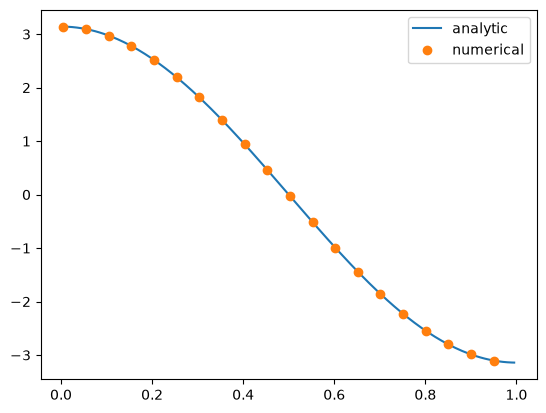

최대 오차 = 1.279e-04


In [2]:
import matplotlib.pyplot as plt

L = 1.0
N = 200

x = np.linspace(0, L, N + 2)[1:-1]
h = L / (N + 1)

f = np.sin(np.pi * x / L)

numerical = derivative_matrix(N, h) @ f
analytic = (np.pi / L) * np.cos(np.pi * x / L)
max_error = np.max(np.abs(numerical - analytic))

plt.plot(x, analytic)
plt.plot(x, numerical, "o", markevery=10)
plt.legend(["analytic", "numerical"])
plt.show()

print(f"최대 오차 = {max_error:.3e}")

In [3]:
def second_derivative_matrix(N, h):
    return (np.eye(N, k=1) - 2 * np.eye(N) + np.eye(N, k=-1)) / (h**2)


print(second_derivative_matrix(6, 1.0))

[[-2.  1.  0.  0.  0.  0.]
 [ 1. -2.  1.  0.  0.  0.]
 [ 0.  1. -2.  1.  0.  0.]
 [ 0.  0.  1. -2.  1.  0.]
 [ 0.  0.  0.  1. -2.  1.]
 [ 0.  0.  0.  0.  1. -2.]]


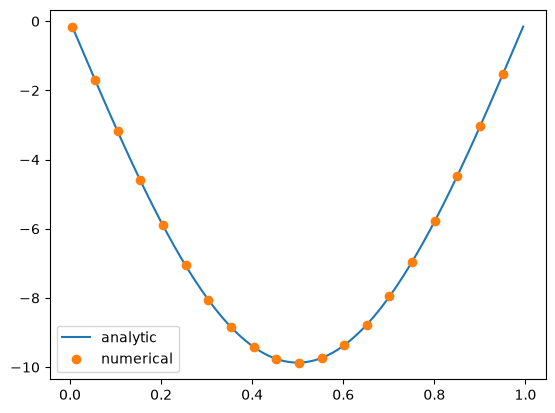

최대 오차 = 2.009e-04


In [4]:
numerical = second_derivative_matrix(N, h) @ f
analytic = -(np.pi / L) ** 2 * np.sin(np.pi * x / L)
max_error = np.max(np.abs(numerical - analytic))

plt.plot(x, analytic)
plt.plot(x, numerical, "o", markevery=10)
plt.legend(["analytic", "numerical"])
plt.show()

print(f"최대 오차 = {max_error:.3e}")

In [5]:
g = np.exp(x)
err = np.abs(second_derivative_matrix(N, h) @ g - np.exp(x))

print(f"전체 최대 오차        = {np.max(err):.3e}")
print(f"양 끝 3점씩을 제외하면 = {np.max(err[3:-3]):.3e}")

전체 최대 오차        = 1.098e+05
양 끝 3점씩을 제외하면 = 5.496e-06
